# Occurrence rate

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from scipy.stats import gaussian_kde

In [3]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.planets import OccurrenceRate

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [4]:
np.random.seed(42)

In [5]:
occ_rate = OccurrenceRate(primary_mass=np.full(1000, 1.0), occ_rate="gpi_nielsen2019")
sma, mass_planet = occ_rate.sample_planets(allow_reject=False)


---------------
Occurrence rate
---------------

Occurrence rate: gpi_nielsen2019

Valid ranges:
   - Semi-major axis (au): 10.00 - 100.00
   - Companion mass (Mjup): 5.00 - 13.00

Primary mass range (Msun): 1.00 - 1.00

--------------
Sample planets
--------------

Number of stars: 1000
Number of planets: 1000

Semi-major axis range (au) = 10.01 - 99.95
Companion mass range (Msun) = 4.77e-03 - 1.24e-02


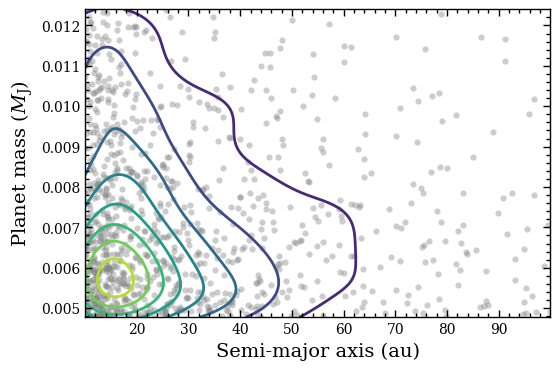

In [6]:
xy = np.vstack([sma, mass_planet])
kde = gaussian_kde(xy)

x_points = np.linspace(np.min(sma), np.max(sma), 200)
y_points = np.linspace(np.min(mass_planet), np.max(mass_planet), 200)
x_grid, y_grid = np.meshgrid(x_points, y_points)

positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = kde(positions).reshape(x_grid.shape)

plt.figure(figsize=(6, 4))
plt.scatter(sma, mass_planet, s=20, alpha=0.4, lw=0.0, color="gray")
plt.contour(x_grid, y_grid, z_grid, levels=10, linewidths=2.0)
plt.xlabel("Semi-major axis (au)", fontsize=14)
plt.ylabel("Planet mass ($M_\mathrm{J}$)", fontsize=14)
plt.show()

In [7]:
source_id = 6643589352010758400  # HD 181327
primary_mass = (1.36, 0.02)  # (Msun)

In [8]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR5')


----------------
Epoch astrometry
----------------

Gaia release: DR5
Reference epoch: 2020.0

Primary mass (Msun): 1.36 +/- 0.02


In [9]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6643589352010758400

INFO: Query finished. [astroquery.utils.tap.core]

RA = 290.746 deg +/- 0.018 mas
Dec = -54.538 deg +/- 0.018 mas
Parallax = 20.931 +/- 0.029 mas
Proper motion in RA = 24.403 +/- 0.022 mas/yr
Proper motion in Dec = -82.186 +/- 0.016 mas/yr
G-band magnitude = 6.936
Pseudocolor = 1.61 um-1

UWE = 1.68
RUWE = 0.96
Astrometric excess noise (mas) = 0.1376 +/- 0.0074
Non single star = 0


In [10]:
model_param = epoch_astrom.simulate_data(
    model_param=None,
    mass_2=None,
    flux_ratio=None,
    occ_rate="cls_fulton2021",
    sigma_per_ccd=None,
    csv_out=None,
)


---------------
Occurrence rate
---------------

Occurrence rate: cls_fulton2021

Valid ranges:
   - Semi-major axis (au): 0.03 - 30.00
   - Companion mass (Mjup): 0.09 - 18.88

Primary mass range (Msun): 1.36 - 1.36

--------------
Sample planets
--------------

Number of stars: 1
Number of planets: 1

Semi-major axis (au) = 7.62
Companion mass (Msun) = 5.07e-03

-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 1.36 +/- 0.02

AL scan uncertainty (per CCD) = 158.77 uas
AL scan uncertainty (per transit) = 56.14 uas

Additional parameters:
   - Primary mass (Msun) = 1.36
   - Companion mass (Msun) = 5.07e-03
   - Mass ratio = 3.73e-03
   - Flux ratio = 3.17e-09
   - Relative semi-major axis (au) = 7.62

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 20.931
   - Proper motion in RA (mas/yr) = 24.403
   - Proper motion in Dec (m

In [11]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 11.365
RUWE = 3.371
F2 estimator = 31.706
Inflation factor = 3.379

Best-fit parameters:
   - RA offset = 0.181 +/- 0.013 mas
   - Dec offset = -0.132 +/- 0.012 mas
   - Parallax = 20.956 +/- 0.017 mas
   - mu in RA = 24.270 +/- 0.004 mas/yr
   - mu in Dec = -82.255 +/- 0.004 mas/yr


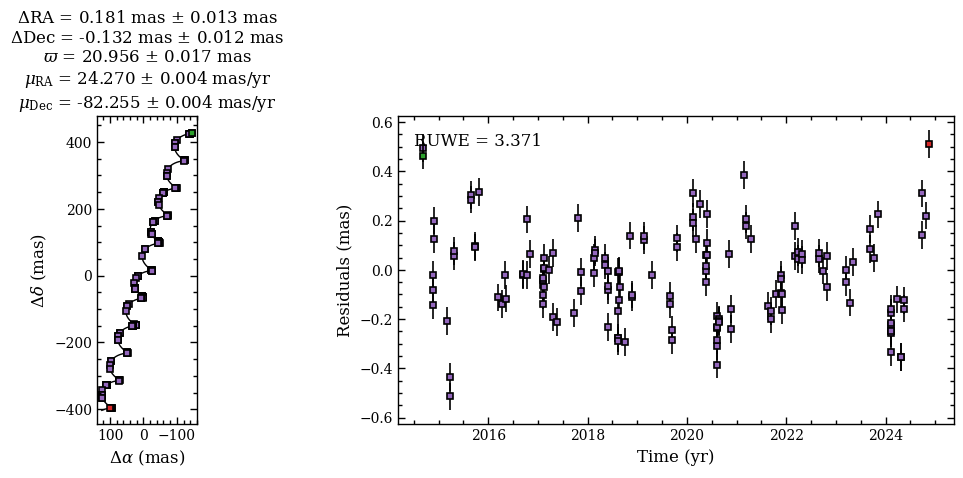

In [12]:
results = leastsq.singl_5param(plot_file='plot.png')


--------------------------
Binary star (7 parameters)
--------------------------

Reduced chi^2 = 2.302
RUWE = 1.517
F2 estimator = 8.108
Inflation factor = 1.521
Significance dmu/dt = 29.246

Best-fit parameters:
   - RA offset = 0.371 +/- 0.013 mas
   - Dec offset = -0.275 +/- 0.011 mas
   - Parallax = 20.917 +/- 0.012 mas
   - mu in RA = 24.274 +/- 0.003 mas/yr
   - mu in Dec = -82.257 +/- 0.003 mas/yr
   - dmu/dt in RA = -0.042 +/- 0.002 mas/yr^2
   - dmu/dt in Dec = 0.040 +/- 0.002 mas/yr^2
   - PM acceleration in RA (mas/yr^2) = -0.042
   - PM acceleration in Dec (mas/yr^2) = 0.040
   - PM acceleration in RA (mas/yr^2) = -0.042
   - PM acceleration in Dec (mas/yr^2) = 0.040


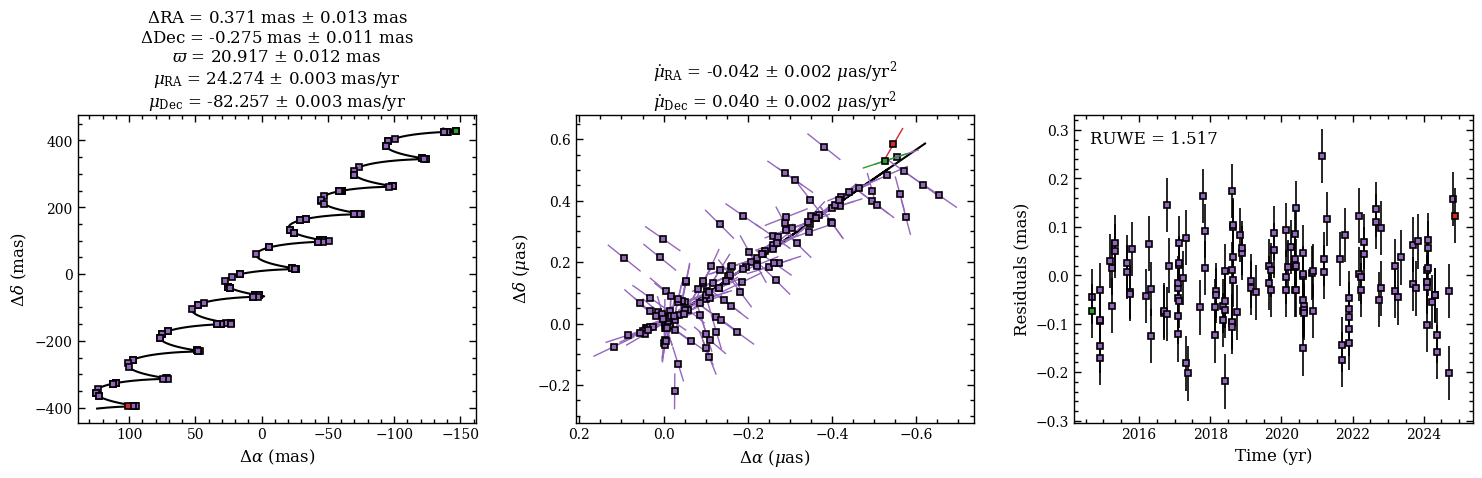

In [13]:
results = leastsq.accel_7param(plot_file='plot.png')


--------------------------
Binary star (9 parameters)
--------------------------

Reduced chi^2 = 1.307
RUWE = 1.143
F2 estimator = 2.374
Inflation factor = 1.146
Significance dmu/dt = 33.782
Significance d^2mu/d^2t = 11.165

Best-fit parameters:
   - RA offset = 0.368 +/- 0.011 mas
   - Dec offset = -0.284 +/- 0.009 mas
   - Parallax = 20.919 +/- 0.010 mas
   - mu in RA = 24.237 +/- 0.006 mas/yr
   - mu in Dec = -82.309 +/- 0.006 mas/yr
   - dmu/dt in RA = -0.037 +/- 0.002 mas/yr^2
   - dmu/dt in Dec = 0.045 +/- 0.002 mas/yr^2
   - d^2mu/d^2t in RA = 0.014 +/- 0.002 mas/yr^3
   - d^2mu/d^2t in Dec = 0.020 +/- 0.002 mas/yr^3
   - PM acceleration in RA (mas/yr^2) = -0.037
   - PM acceleration in Dec (mas/yr^2) = 0.045
   - PM acceleration derivative in RA (mas/yr^3) = 0.014
   - PM acceleration derivative in Dec (mas/yr^3) = 0.020
   - PM acceleration in RA (mas/yr^2) = -0.037
   - PM acceleration in Dec (mas/yr^2) = 0.045
   - PM acceleration derivative in RA (mas/yr^3) = 0.014
   - P

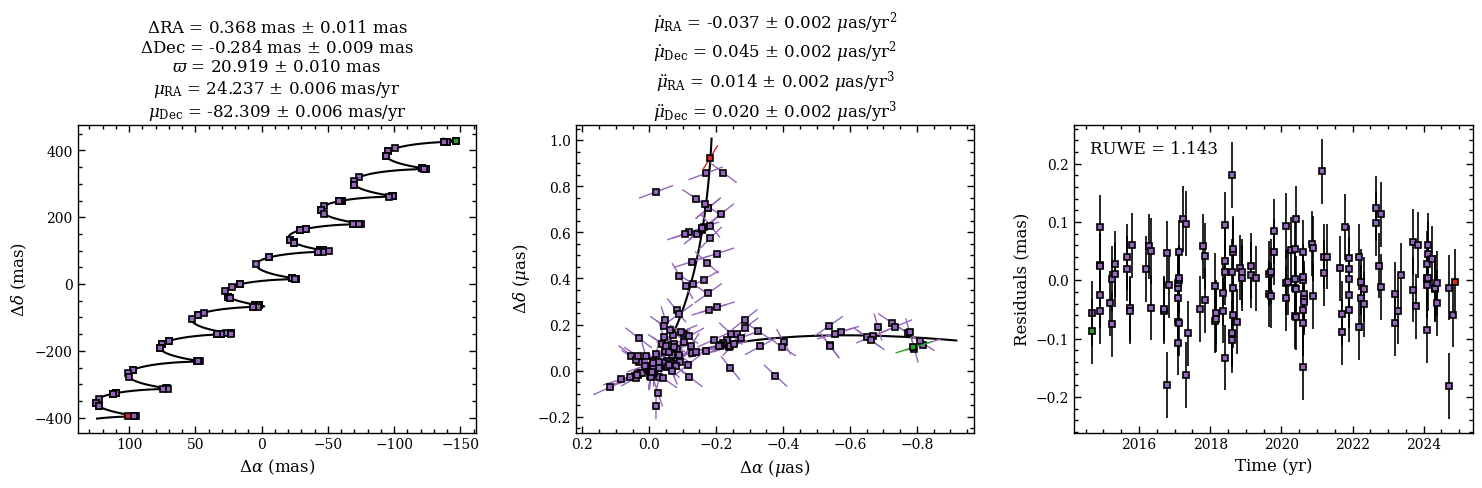

In [14]:
results = leastsq.accel_9param(plot_file='plot.png')